# **PRÁCTICA 4.- CLIMA (VISUALIZACIÓN DE DATOS)**

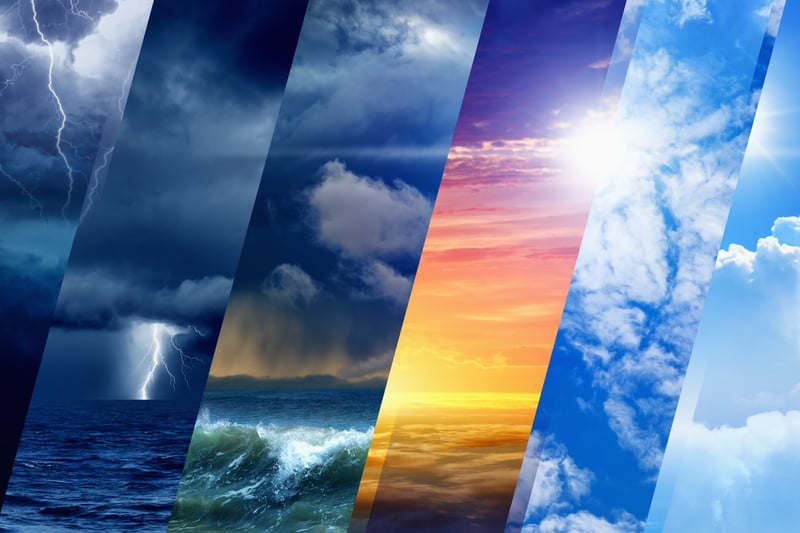

# **DESCRIPCION**
El objetivo de esta actividad es poner en práctica lo aprendido en clase con respecto a visualización de datos. Deberás utilizar el dataset Weather_Classification que se encuentra en Classroom.


Descripción de las características del dataset

*   Id (numeric): record Id.
*   Temperature (numeric): The temperature in degrees Celsius, ranging from extreme cold to extreme heat.
*   Humidity (numeric): The humidity percentage, including values above 100% to introduce outliers.
*   Wind Speed (numeric): The wind speed in kilometers per hour, with a range including unrealistically high values.
*   Precipitation (%) (numeric): The precipitation percentage, including outlier values.
*   Cloud Cover (categorical): The cloud cover description.
*   Atmospheric Pressure (numeric): The atmospheric pressure in hPa, covering a wide range.
*   UV Index (numeric): The UV index, indicating the strength of ultraviolet radiation.
*   Season (categorical): The season during which the data was recorded.
*   Visibility (km) (numeric): The visibility in kilometers, including very low or very high values.
*   Location (categorical): The type of location where the data was recorded.
*   Weather Type (categorical): The target variable for classification, indicating the weather type.

## **Descripción de la actividad**

En este proyecto, analizaremos un dataset que se usa para realizar la predicción del tipo de clima con base en una serie de características.


Usando el que se encuentra en la plataforma Classroom y que lleva por nombre Weather_Classifiction haz lo siguiente:
1.   **Importa de librerías y herramientas**. Importa las librerías que se usarán para este proyecto y importa el dataser usando Pandas.
2.   **Análisis Exploratorio de los datos.** Realiza un análisis exploratorio de los datos (EDA) básico donde muestres los primeros y últimos 10 registros, que verifiques el tipo de datos que tiene el dataset, que verifiques la cantidad de datos nulos que contiene el dataset.
3.   **Balanceo de categorías.** Haz un análisis a través de una gráfica de barras para analizar si las categorías de predicción incluidas en el dataset están balanceadas.
4.   **Matriz de correlación.**  Representar la matriz de correlaciones del dataset.
5.   **Función de conversión.** Crea una función para convertir los valores de la temperatura del dataset que se encuentran en grados Celsius a grados  Fahrenheit y agrega la conversión en una nueva columna.
6.   **Gráficos de líneas.**   Con Matplotlib, representa diagramas de líneas que muestren los valores de las características Temperature, Humidity y Wind Speed. Con Matplotlib, representa los valores de las características en varias subplots. Usando Matplotlib, representa los 3 plots en subplots una al lado de la otra (todas las figuras en una fila).
7.   **Diagrama de dispersión**.   Representa el diagrama de dispersión entre la temperatura y la humedad utilizando tanto Mathplotlib como Seaborn.
8. **Histograma.**  Usando Matplotlib, representa el histograma para las características precipitación y humedad usando 30 divisiones con color azul. Muestra la media y la desviación estándar para ambas acciones en la parte superior de la figura.
9. **Gráficos 3D.**  Representa un gráfico 3D que muestre todos los valores de la temperatura, humedad y precipitación.
10. **Escalamiento y normalización**. Haz el escalamiento de las características temperatura, humedad, velocidad del viento y precipitación. Escala las características presión atmosférica, UV index y visibilidad utilizando la normalización.
11.   **Codificación ONE-HOT.**  Aplica la codificación ONE-HOT a cada una de las columnas del dataset que lo requieran.
12. **Gráficas de burbuja**. Crea un gráfico de burbuja definiendo una característica para el uso de colores.
13.   **Gráfico box plot**. Crea un gráfico de bigotes para representar la información del dataset.
14. **Gráfico de pila**. Crea un gráfico stacked para representar datos del dataset.

## **1.  Importar librerías y dataset**

Importa las librerías que se usarán para este proyecto y importa el dataser usando Pandas.

In [1]:
# Importamos las librerías que se utilizarán para el proyecto
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configurar visualización de Pandas y estilo gráfico
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [2]:
# Leemos el dataset que utilizaremos para el presente ejercicio
try:
    clima_ds = pd.read_csv('Weather_Classification.csv')
except FileNotFoundError:
    try:
        clima_ds = pd.read_csv('Weather_Classifiction.csv')
    except FileNotFoundError:
        clima_ds = pd.read_csv('weather_classification_data.csv')

clima_ds.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## **2. Análisis exploratorio de datos**

Realiza un análisis exploratorio de los datos (EDA) básico donde muestres los primeros y últimos 10 registros, que verifiques el tipo de datos que tiene el dataset, que verifiques la cantidad de datos nulos que contiene el dataset.

In [3]:
# Mostrar los primeros 10 registros
clima_ds.head(10)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [4]:
# Mostrar los últimos 10 registros
clima_ds.tail(10)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
13190,30.0,24,3.5,16.0,partly cloudy,1017.54,11,Summer,6.5,mountain,Sunny
13191,27.0,48,6.5,14.0,clear,1029.37,8,Summer,8.0,inland,Sunny
13192,31.0,24,8.0,5.0,clear,1029.61,8,Summer,9.0,inland,Sunny
13193,-5.0,65,15.5,50.0,overcast,982.57,1,Winter,5.0,inland,Snowy
13194,29.0,62,13.0,17.0,overcast,1002.81,2,Spring,5.0,coastal,Cloudy
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy
13199,-5.0,38,0.0,92.0,overcast,1015.37,5,Autumn,10.0,mountain,Rainy


In [5]:
# Verificar el tipo de datos de cada característica incluida en el dataset
clima_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  str    
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  str    
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  str    
 10  Weather Type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.1 MB


In [6]:
# Mostrar la cantidad de registros que contienen valores nulos
clima_ds.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

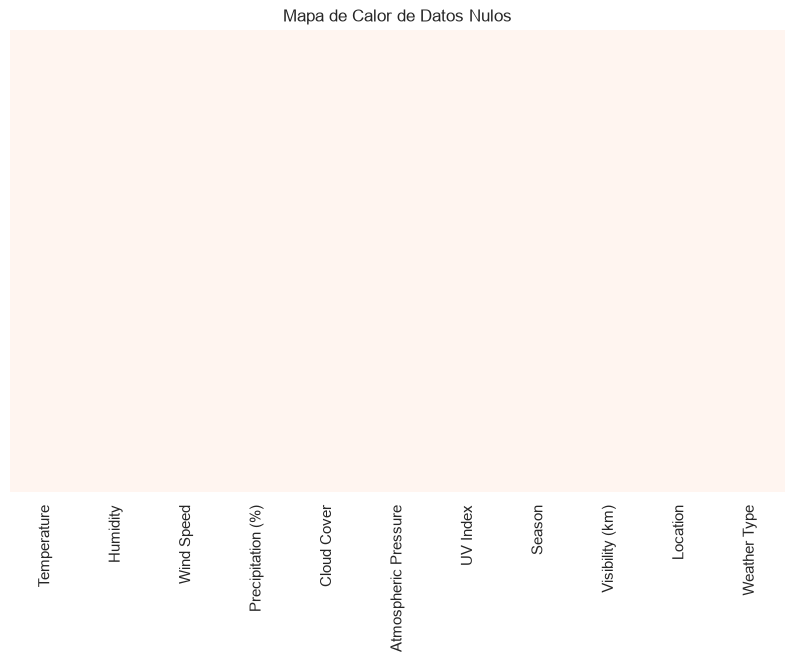

In [7]:
# Generar un mapa de calor para reflejar los datos nulos del dataset pero que sea color rojo
plt.figure(figsize=(10, 6))
sns.heatmap(clima_ds.isnull(), cbar=False, cmap='Reds', yticklabels=False)
plt.title('Mapa de Calor de Datos Nulos')
plt.show()

In [8]:
# Mostramos un análisis estadístico del dataset
clima_ds.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


## **3. Balanceo de categorías**

Haz un análisis a través de una gráfica de barras para analizar si las categorías de predicción incluidas en el dataset están balanceadas.

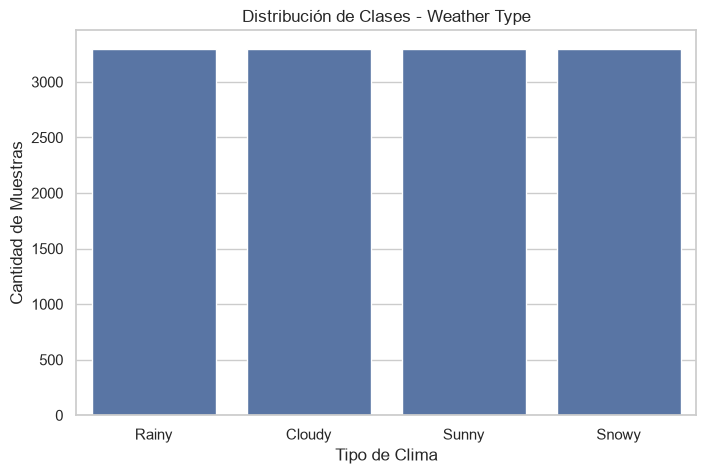

In [9]:
# Imprime un countplot para saber cuántas muestras pertenecen a las clases especificadas en la característica Tipo de clima
plt.figure(figsize=(8, 5))
sns.countplot(x=clima_ds['Weather Type'])
plt.title('Distribución de Clases - Weather Type')
plt.xlabel('Tipo de Clima')
plt.ylabel('Cantidad de Muestras')
plt.show()

## **4. Matriz de correlación**

Representar la matriz de correlaciones del dataset.

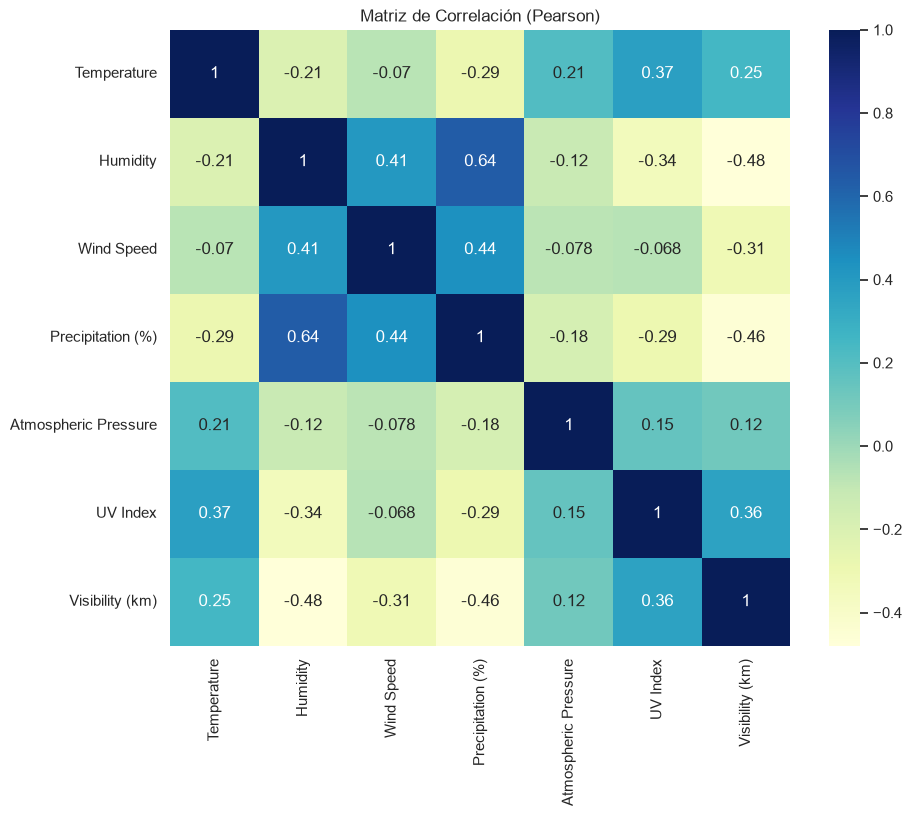

In [10]:
# Dibuja la matriz de correlación pero coloca de método pearson.
plt.figure(figsize=(10, 8))
correlations_pearson = clima_ds.corr(numeric_only=True, method='pearson')
sns.heatmap(correlations_pearson, annot=True, cmap='YlGnBu')
plt.title('Matriz de Correlación (Pearson)')
plt.show()

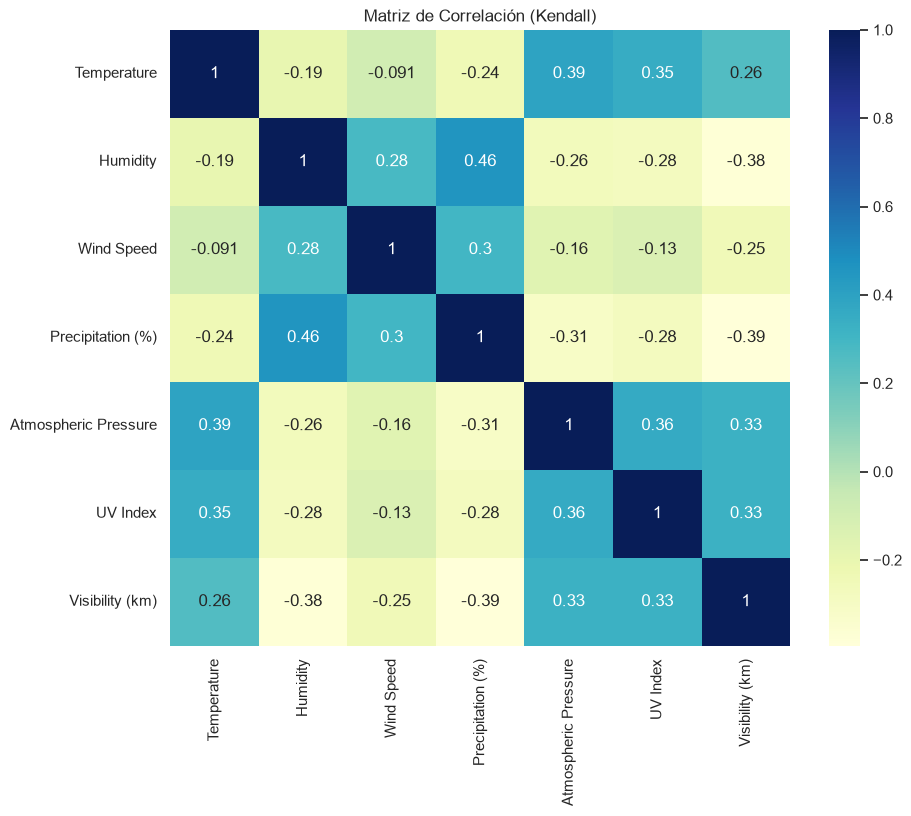

In [11]:
# Dibuja la matriz de correlación pero coloca de método kendall.
plt.figure(figsize=(10, 8))
correlations_kendall = clima_ds.corr(numeric_only=True, method='kendall')
sns.heatmap(correlations_kendall, annot=True, cmap='YlGnBu')
plt.title('Matriz de Correlación (Kendall)')
plt.show()

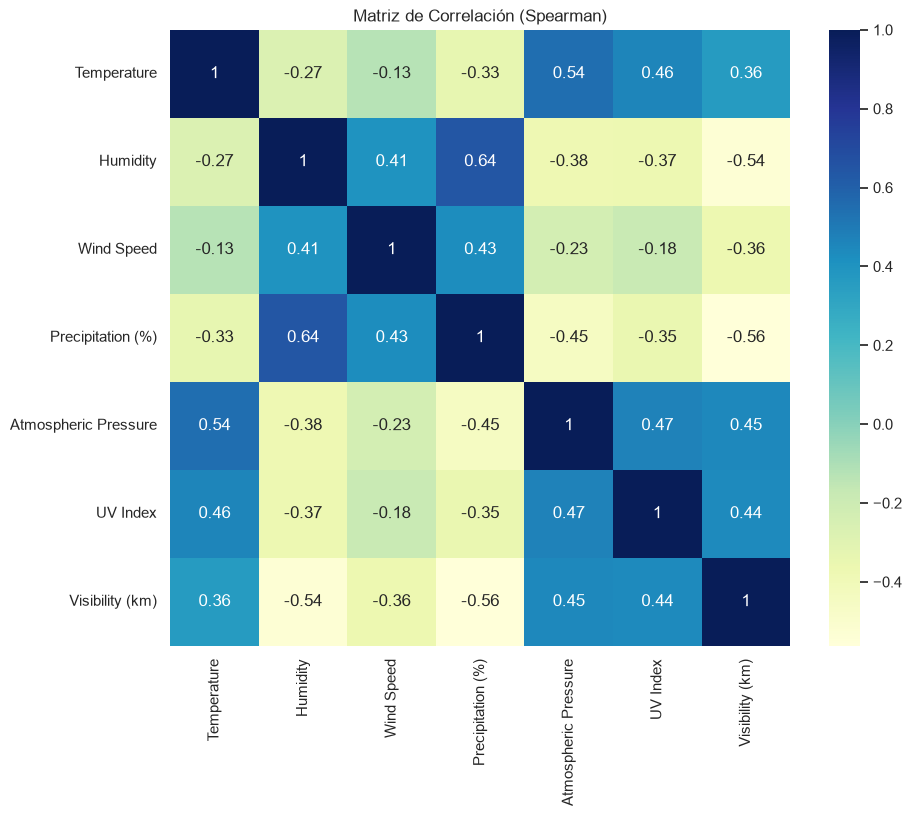

In [12]:
# Dibuja la matriz de correlación pero coloca de método spearman.
plt.figure(figsize=(10, 8))
correlations_spearman = clima_ds.corr(numeric_only=True, method='spearman')
sns.heatmap(correlations_spearman, annot=True, cmap='YlGnBu')
plt.title('Matriz de Correlación (Spearman)')
plt.show()

## **5. Función de conversión**

Crea una función para convertir los valores de la temperatura del dataset que se encuentran en grados Celsius a grados Fahrenheit y agrega la conversión en una nueva columna.

In [13]:
# Definimos la función que convierte de Celsius a Fahrenheit
def celsius_a_fahrenheit(celsius):
    return (celsius * 9/5) + 32

In [14]:
# Definimos una nueva columna donde se guardará la conversión
clima_ds['Temperature_Fahrenheit'] = clima_ds['Temperature'].apply(celsius_a_fahrenheit)

In [15]:
# Visualizamos la nueva estructura del dataset
clima_ds.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Temperature_Fahrenheit
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,57.2
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,102.2
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,86.0
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,100.4
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,80.6


## **6. Gráficos de líneas**

Con Matplotlib, representa diagramas de líneas que muestren los valores de las características Temperature, Humidity y Wind Speed. Con Matplotlib, representa los valores de las características en varias subplots. Usando Matplotlib, representa los 3 plots en subplots una al lado de la otra (todas las figuras en una fila).

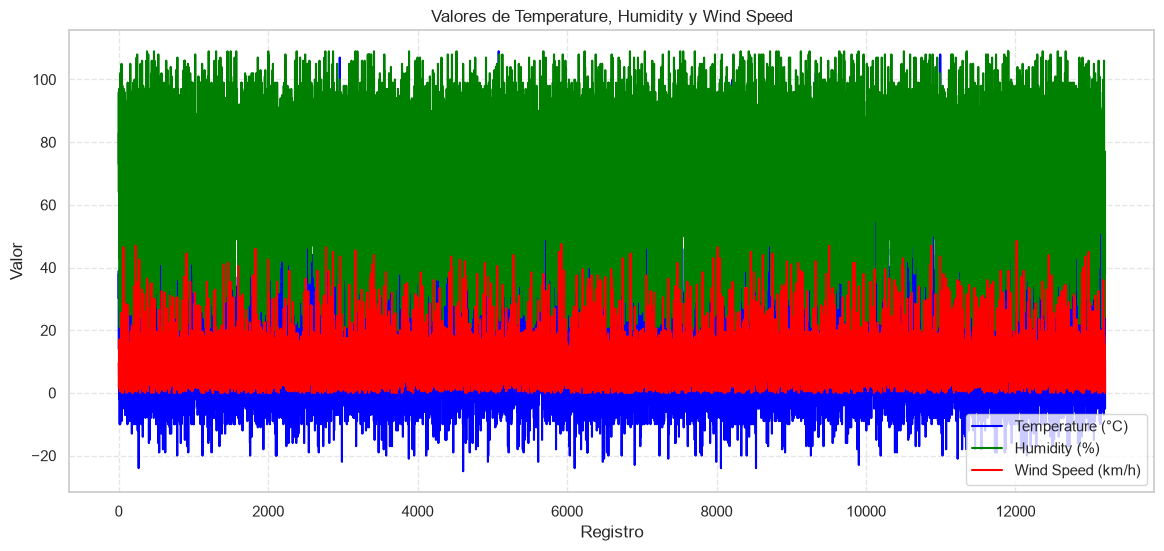

In [16]:
# Graficamos el valor de las características en la misma gráfica
plt.figure(figsize=(14, 6))
plt.plot(clima_ds['Temperature'], label='Temperature (°C)', color='blue')
plt.plot(clima_ds['Humidity'], label='Humidity (%)', color='green')
plt.plot(clima_ds['Wind Speed'], label='Wind Speed (km/h)', color='red')
plt.title('Valores de Temperature, Humidity y Wind Speed')
plt.xlabel('Registro')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

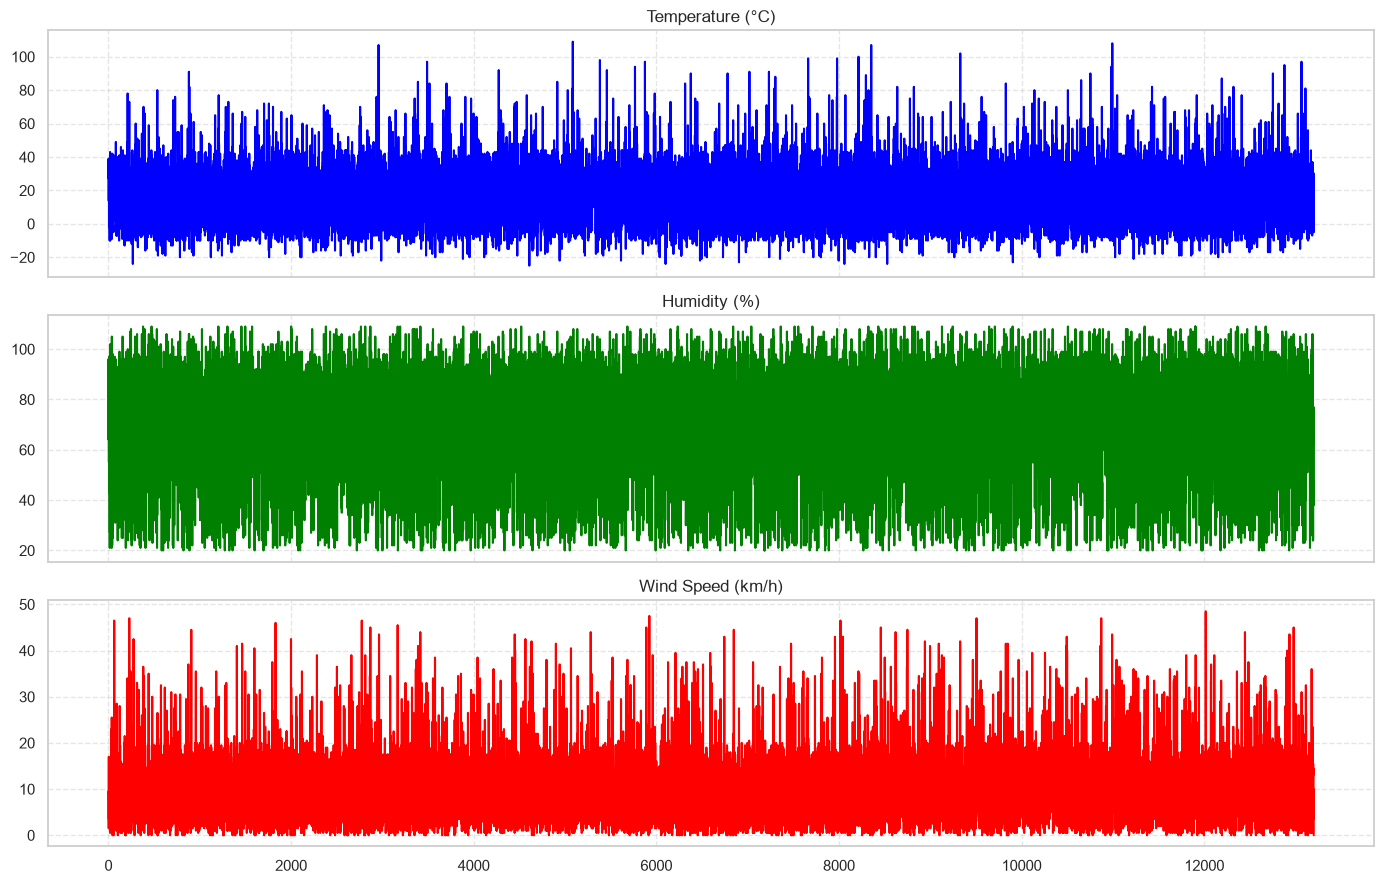

In [17]:
# Graficamos el valor de las características de forma separada
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(clima_ds['Temperature'], color='blue')
axes[0].set_title('Temperature (°C)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(clima_ds['Humidity'], color='green')
axes[1].set_title('Humidity (%)')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(clima_ds['Wind Speed'], color='red')
axes[2].set_title('Wind Speed (km/h)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

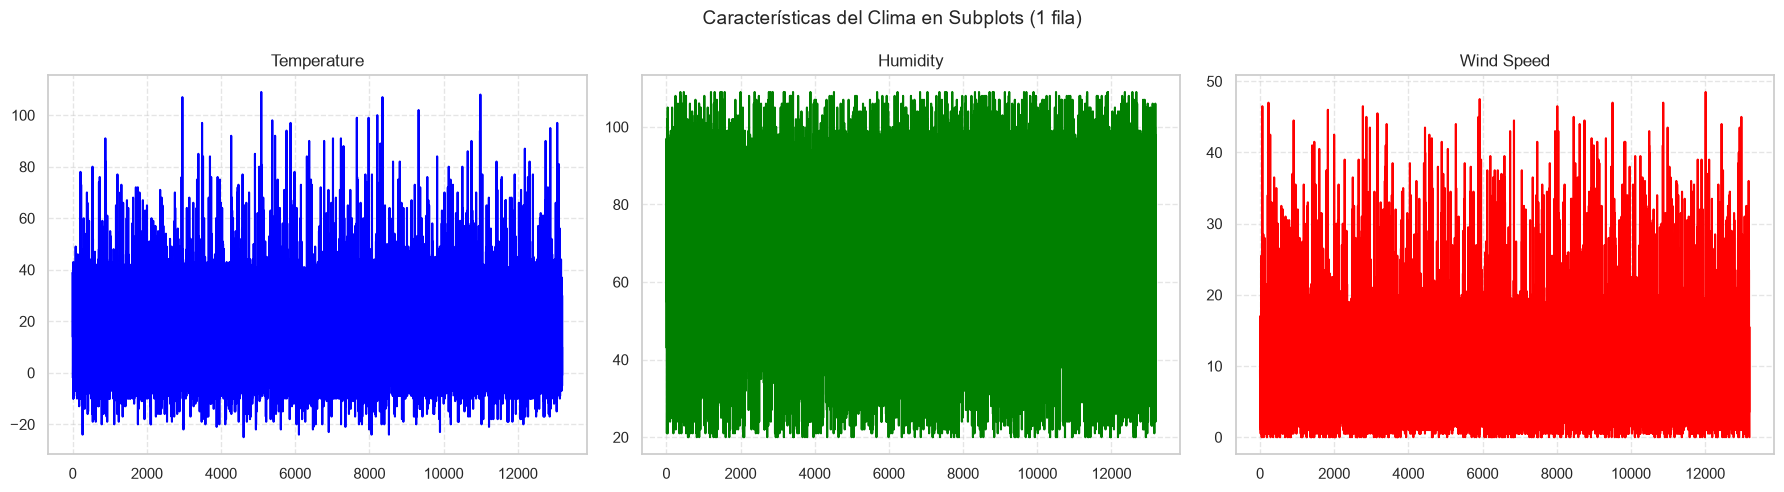

In [18]:
# Ahora graficamos los 3 plots en subplots una al lado de la otra (todas las figuras en una fila)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(clima_ds['Temperature'], color='blue')
axes[0].set_title('Temperature')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(clima_ds['Humidity'], color='green')
axes[1].set_title('Humidity')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(clima_ds['Wind Speed'], color='red')
axes[2].set_title('Wind Speed')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Características del Clima en Subplots (1 fila)', fontsize=14)
plt.tight_layout()
plt.show()

## **7. Diagrama de dispersión**

Representa el diagrama de dispersión entre la temperatura y la humedad utilizando tanto Mathplotlib como Seaborn

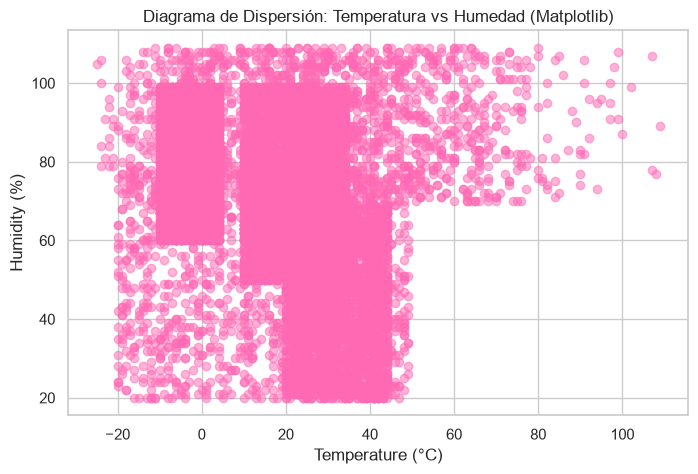

In [19]:
# Diagrama mediante Matplotlib
plt.figure(figsize=(8, 5))
plt.scatter(clima_ds['Temperature'], clima_ds['Humidity'], color='hotpink', alpha=0.5)
plt.title('Diagrama de Dispersión: Temperatura vs Humedad (Matplotlib)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True)
plt.show()

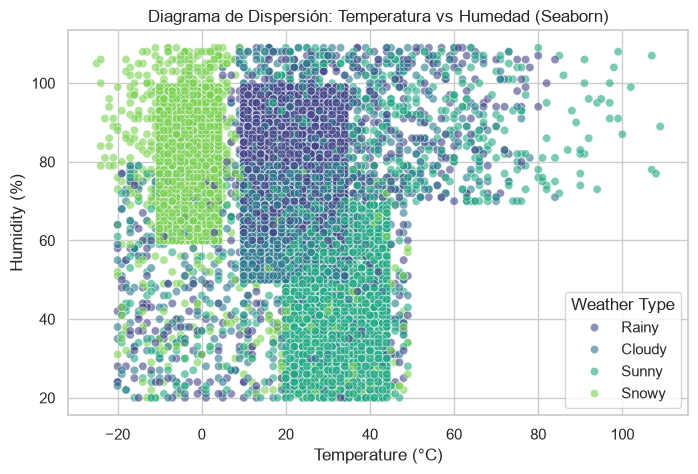

In [20]:
# Ahora graficamos con Seaborn el diagrama de dispersión entre la temperatura y la humedad
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temperature', y='Humidity', data=clima_ds, hue='Weather Type', alpha=0.6, palette='viridis')
plt.title('Diagrama de Dispersión: Temperatura vs Humedad (Seaborn)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.show()

## **8. Histograma.**

Usando Matplotlib, representa el histograma para las características precipitación y humedad usando 30 divisiones con color azul. Muestra la media y la desviación estándar para ambas acciones en la parte superior de la figura.

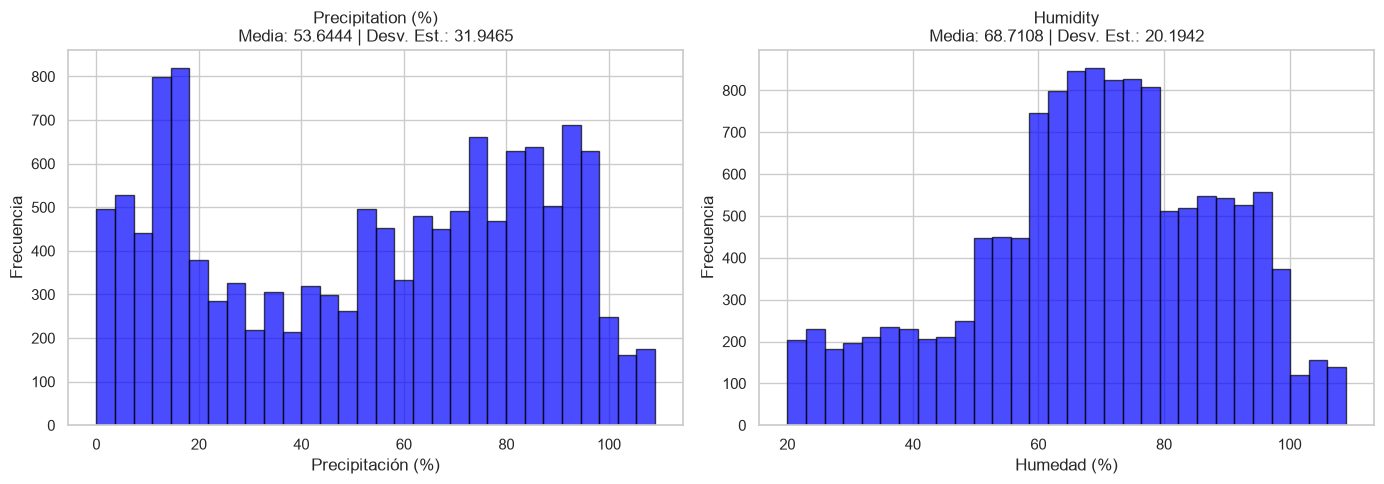

In [21]:
# Primeramente definimos el tamaño del gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Realizamos los cálculos de la media y desviación estándar de los datos de Precipitación
precip_mean = clima_ds['Precipitation (%)'].mean()
precip_std = clima_ds['Precipitation (%)'].std()

# Realizamos los cálculos de la media y desviación estándar de los datos de Humedad
humid_mean = clima_ds['Humidity'].mean()
humid_std = clima_ds['Humidity'].std()

# Graficamos el histograma
axes[0].hist(clima_ds['Precipitation (%)'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title(f"Precipitation (%)\nMedia: {precip_mean:.4f} | Desv. Est.: {precip_std:.4f}")
axes[0].set_xlabel('Precipitación (%)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(clima_ds['Humidity'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title(f"Humidity\nMedia: {humid_mean:.4f} | Desv. Est.: {humid_std:.4f}")
axes[1].set_xlabel('Humedad (%)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## **9. Gráficos 3D.**

 Representa un gráfico 3D que muestre todos los valores de la temperatura, humedad y precipitación.

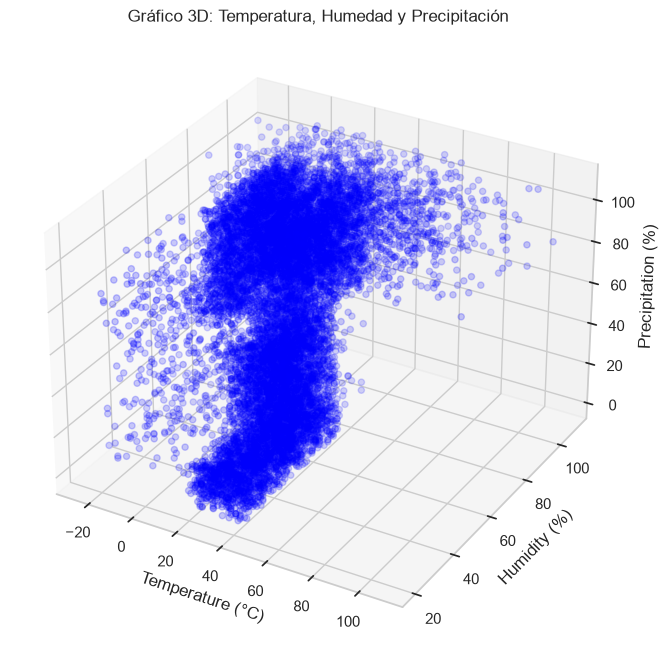

In [22]:
from mpl_toolkits.mplot3d import Axes3D

# Representa un gráfico 3D que muestre todos los datos de temperatura, humedad y precipitación.
fig = plt.figure(figsize=(10, 8))

# 111 significa 1 fila, 1 columna y en la posición 1 de la matriz 1x1.
ax = fig.add_subplot(111, projection='3d')

# Retorna el array de valores de cada una de las columnas seleccionadas
x = clima_ds['Temperature'].values
y = clima_ds['Humidity'].values
z = clima_ds['Precipitation (%)'].values

ax.scatter(x, y, z, c='blue', marker='o', alpha=0.5)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Humidity (%)')
ax.set_zlabel('Precipitation (%)')
ax.set_title('Gráfico 3D: Temperatura, Humedad y Precipitación')

plt.show()

## **10. Escalamiento y normalización.**

Haz el escalamiento de las características temperatura, humedad, velocidad del viento y precipitación. Escala las características presión atmosférica, UV index y visibilidad utilizando la normalización.

In [23]:
# Cargamos la librería preprocessing para el escalamiento de datos (Estandarización)
scaler_std = StandardScaler()
cols_std = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)']
clima_ds[[f'{c}_Estandarizada' for c in cols_std]] = scaler_std.fit_transform(clima_ds[cols_std])
clima_ds[[f'{c}_Estandarizada' for c in cols_std]].head()

,Temperature_Estandarizada,Humidity_Estandarizada,Wind Speed_Estandarizada,Precipitation (%)_Estandarizada
0,-0.294931,0.212404,-0.048086,0.887629
1,1.143035,1.351385,-0.192836,0.543291
2,0.625367,-0.233285,-0.409962,-1.178401
3,1.085516,0.707613,-1.206089,0.887629
4,0.452811,0.261924,1.037543,0.386773


In [24]:
# Cargamos la librería preprocessing para el escalamiento de datos (Normalización)
scaler_minmax = MinMaxScaler()
cols_norm = ['Atmospheric Pressure', 'UV Index', 'Visibility (km)']
clima_ds[[f'{c}_Normalizada' for c in cols_norm]] = scaler_minmax.fit_transform(clima_ds[cols_norm])
clima_ds[[f'{c}_Normalizada' for c in cols_norm]].head()

,Atmospheric Pressure_Normalizada,UV Index_Normalizada,Visibility (km)_Normalizada
0,0.527951,0.142857,0.175
1,0.529480,0.500000,0.500
2,0.547746,0.357143,0.275
3,0.566614,0.500000,0.050
4,0.477461,0.071429,0.125


In [25]:
# Mostramos los valores estadísticos para verificar los valores
columnas_escaladas = [f'{c}_Estandarizada' for c in cols_std] + [f'{c}_Normalizada' for c in cols_norm]
clima_ds[columnas_escaladas].describe().round(2)

,Temperature_Estandarizada,Humidity_Estandarizada,Wind Speed_Estandarizada,Precipitation (%)_Estandarizada,Atmospheric Pressure_Normalizada,UV Index_Normalizada,Visibility (km)_Normalizada
count,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00
mean,-0.00,0.00,0.00,0.00,0.52,0.29,0.27
std,1.00,1.00,1.00,1.00,0.09,0.28,0.17
min,-2.54,-2.41,-1.42,-1.68,0.00,0.00,0.00
25%,-0.87,-0.58,-0.70,-1.08,0.49,0.07,0.15
50%,0.11,0.06,-0.12,0.14,0.52,0.21,0.25
75%,0.68,0.76,0.53,0.89,0.54,0.50,0.38
max,5.17,2.00,5.60,1.73,1.00,1.00,1.00


## **11. Codificación ONE-HOT.**

Aplica la codificación ONE-HOT a cada una de las columnas del dataset que lo requieran.

In [26]:
# Procedemos a aplicar ONE-HOT
columnas_categoricas = ['Cloud Cover', 'Season', 'Location']
clima_encoded_df = pd.get_dummies(clima_ds, columns=columnas_categoricas, drop_first=False)
clima_encoded_df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Temperature_Fahrenheit,Temperature_Estandarizada,Humidity_Estandarizada,Wind Speed_Estandarizada,Precipitation (%)_Estandarizada,Atmospheric Pressure_Normalizada,UV Index_Normalizada,Visibility (km)_Normalizada,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3.5,Rainy,57.2,-0.294931,0.212404,-0.048086,0.887629,0.527951,0.142857,0.175,False,False,False,True,False,False,False,True,False,True,False
1,39.0,96,8.5,71.0,1011.43,7,10.0,Cloudy,102.2,1.143035,1.351385,-0.192836,0.543291,0.529480,0.500000,0.500,False,False,False,True,False,True,False,False,False,True,False
2,30.0,64,7.0,16.0,1018.72,5,5.5,Sunny,86.0,0.625367,-0.233285,-0.409962,-1.178401,0.547746,0.357143,0.275,True,False,False,False,False,True,False,False,False,False,True
3,38.0,83,1.5,82.0,1026.25,7,1.0,Sunny,100.4,1.085516,0.707613,-1.206089,0.887629,0.566614,0.500000,0.050,True,False,False,False,False,True,False,False,True,False,False
4,27.0,74,17.0,66.0,990.67,1,2.5,Rainy,80.6,0.452811,0.261924,1.037543,0.386773,0.477461,0.071429,0.125,False,False,True,False,False,False,False,True,False,False,True


## **12. Gráficas de burbuja.**

Crea un gráfico de burbuja definiendo una característica para el uso de colores.

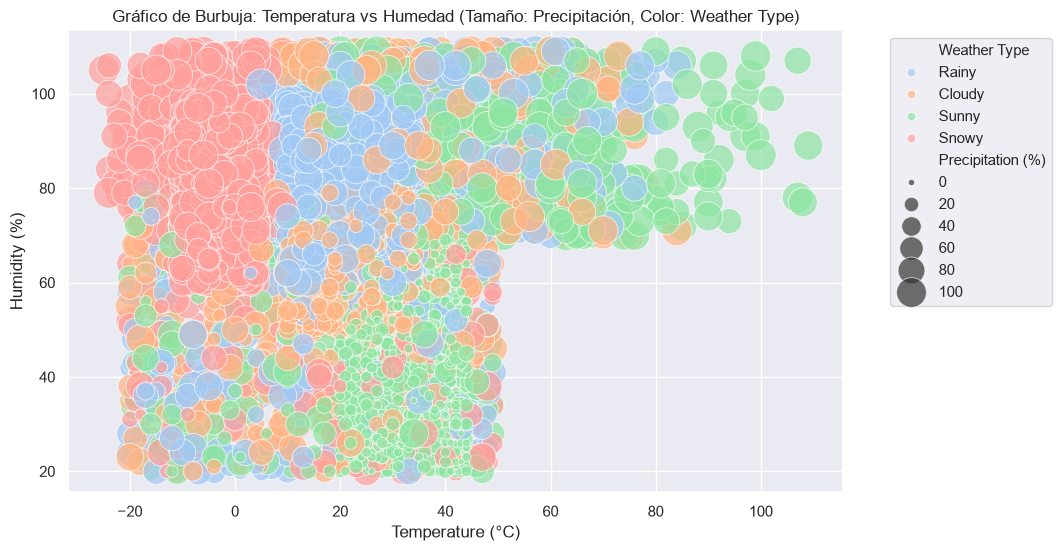

In [27]:
# Gráfico de burbuja definiendo una característica para el uso de colores
sns.set_theme(style="darkgrid", palette="pastel")
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clima_ds,
    x="Temperature",
    y="Humidity",
    size="Precipitation (%)",
    hue="Weather Type",
    legend=True,
    sizes=(20, 500),
    alpha=0.7
)
plt.title('Gráfico de Burbuja: Temperatura vs Humedad (Tamaño: Precipitación, Color: Weather Type)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## **13. Gráfico box plot.**

Crea un gráfico de bigotes para representar la información del dataset.

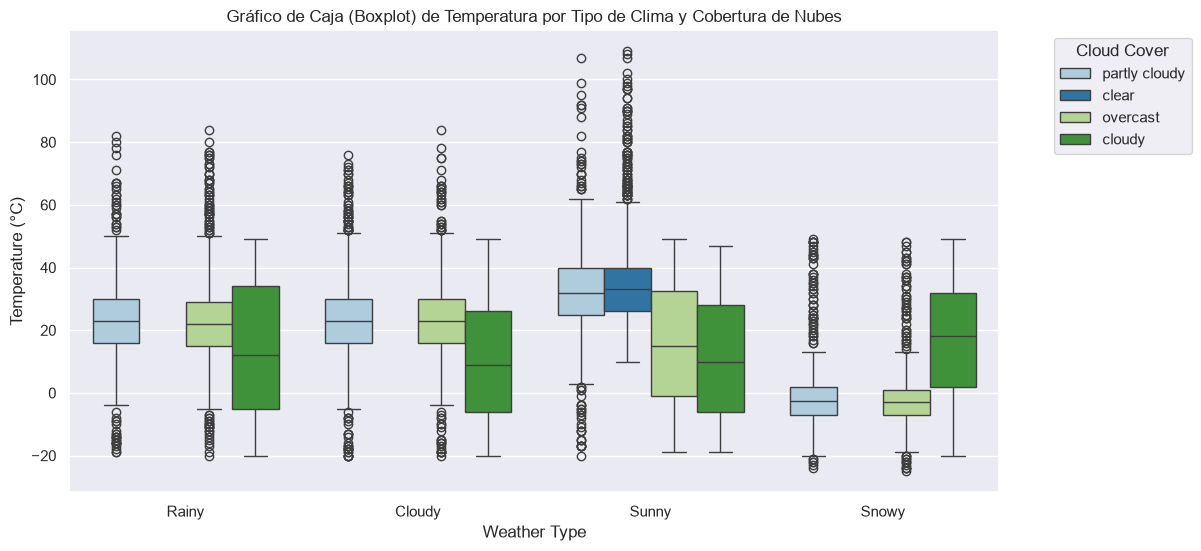

In [28]:
# Gráfico box plot (bigotes) para representar la información del dataset
sns.set_palette("Paired")
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x="Weather Type", y="Temperature", hue="Cloud Cover", data=clima_ds)
ax.set_xlabel("Weather Type")
ax.set_ylabel("Temperature (°C)")
plt.title("Gráfico de Caja (Boxplot) de Temperatura por Tipo de Clima y Cobertura de Nubes")
plt.legend(title="Cloud Cover", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## **14. Gráfico de pila.**

Crea un gráfico stacked para representar datos del dataset.

In [29]:
# Agrupamos los datos por Cloud cover y weather type.
clima_agrupado = clima_ds.groupby(['Cloud Cover', 'Weather Type'])['Temperature'].mean().unstack().fillna(0)
clima_agrupado

Weather Type,Cloudy,Rainy,Snowy,Sunny
Cloud Cover,,,,
clear,0.000000,0.000000,0.000000,34.317906
cloudy,11.521739,13.104762,15.878505,11.177570
overcast,23.209195,23.100319,-2.503817,14.970874
partly cloudy,23.105623,23.119760,-0.735795,32.462671


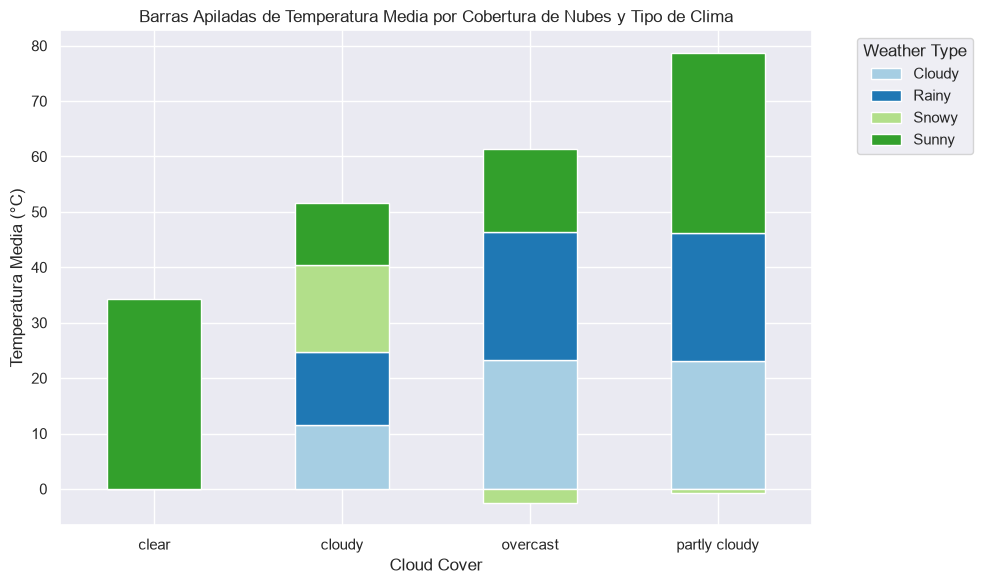

In [30]:
# Gráfico de Barras apiladas de temperatura por tipo de clima y tipo de nubes
clima_agrupado.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Barras Apiladas de Temperatura Media por Cobertura de Nubes y Tipo de Clima')
plt.xlabel('Cloud Cover')
plt.ylabel('Temperatura Media (°C)')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Weather Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()